In [1]:
include("CRD_STA.jl")
include("Fun.jl")
using LinearAlgebra
using NonlinearEigenproblems
using DelimitedFiles
using DifferentialEquations
using Plots
using Arpack

In [2]:
function BF(N_cheb,Ro,Tw,Mr)
    gamma = 1.4
    sigma = 0.72
    Co = 2 - Ro - Ro^2
    u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    return F,G,H,T,rho,x,lam,kappa,D,D2
end
function eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
    cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
    L0,L1,L2 = assemble_mat(cof,D,D2,be,omega)
    nep = PEP([L0,L1,L2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-12)
    # eigval = conj(eigval)
    return cof,eigval,eigvec
end
function integral(x,y)
    inte_progress =  zeros(ComplexF64,length(x),1)
    for i = 1 : length(x)
        inte_progress[i] = x[1:i,1]' * y[1:i,1]
    end
    return inte_progress
end
function mat_diff(A,B,N_cheb)
    block_size = N_cheb + 1
    nblock = 5
    C = zeros(ComplexF64,block_size*nblock,block_size*nblock)
    for i = 0 : nblock - 1
        for j = 0 : nblock - 1
        C[1+block_size*i:block_size*(i+1),1+block_size*j:block_size*(j+1)] = (B * A[1+block_size*i:block_size*(i+1),1+block_size*j:block_size*(j+1)])
        end
    end

    return C'
end
function eig_full(eigvec,N_cheb,num)
    N = N_cheb + 1
    eigvec = eigvec[:,num]
    insert!(eigvec,5N-8,0im)
    insert!(eigvec,4N-6,0im)
    insert!(eigvec,4N-6,0im)
    insert!(eigvec,3N-4,0im)
    insert!(eigvec,3N-4,0im)
    insert!(eigvec,2N-2,0im)
    insert!(eigvec,2N-2,0im)
    insert!(eigvec,N,0im)
    insert!(eigvec,N,0im)
    rho = eigvec[1:N]
    u = eigvec[N+1:2N]
    v = eigvec[2N+1:3N]
    w = eigvec[3N+1:4N]
    T = eigvec[4N+1:5N]
    return eigvec,(rho,u,v,w,T)
end

eig_full (generic function with 1 method)

In [3]:
function Bi_linear(C,H1_A,vec_A)
    q_all = []
    for i = 1 : size(C.vectors,2)
        Q = (vec_A') * (H1_A' * C.vectors[:,i])
        q_all = [q_all ; Q]
    end 
    ind = findmax(abs.(q_all))
    Q = q_all[ind[2]]
    return q_all,Q,C.values[ind[2]]
end

Bi_linear (generic function with 1 method)

In [4]:
N_cheb = 199
Ro = -1
Tw = 1.0
Mr = 0.3
gamma = 1.4
sigma = 0.72
Co = 2-Ro-Ro^2
F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)

([0.0; 0.0; … ; 6.357652889550219e-5; 0.0;;], [0.0; 0.0; … ; -7.675512473060131e-5; 0.0;;], [0.0; 0.0; … ; -7.926212270407343e-9; -3.176003061707337e-25;;], [0.0; 0.0; … ; 1.0000010483342074; 1.0;;], [Inf; Inf; … ; 0.9999989516668916; 1.0;;], [1.0e15, 32098.02822234181, 8023.507086739387, 3565.262468925685, 2004.8768963184737, 1282.6413363009576, 890.3158977157145, 653.7560851040269, 500.2197228633434, 394.95575428164466  …  0.010127716729372129, 0.007996485978408277, 0.006118489894229456, 0.004492787346898903, 0.0031185647045616845, 0.0019951349668127466, 0.0011219370340510482, 0.0004985351114864573, 0.00012461824671260657, 0.0], [-0.0; -0.0; … ; -0.6666673655561383; -0.6666666666666666;;], [0.0; 0.0; … ; 1.3888903449086214; 1.3888888888888888;;], [-0.0 0.0 … -0.0 0.0; -1.0336327575570742e12 5.1678417640306213e11 … 1.2881752849875301e8 -6.440475099573966e7; … ; 0.2500467347543978 -0.5001246318361743 … -2006.3767638954864 4013.003574525539; -0.5 1.0000623091233563 … -16050.014111170905

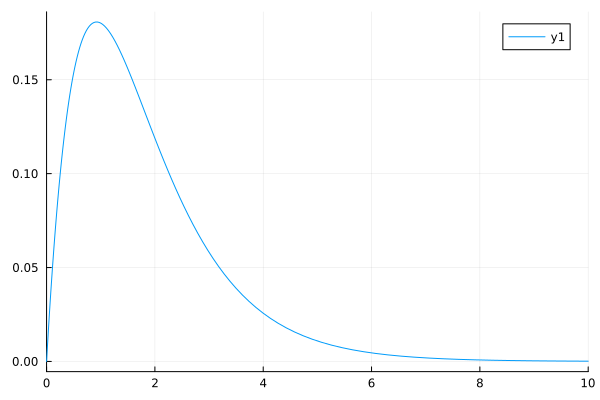

In [8]:
plot(z,F,xlims=[0,10])

In [12]:
n = 10
num = 1
R = 400
omega = 7.9/R
be = n/R
Ma = Mr/R
c = 0.2
cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega)
L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
nep = PEP([L0,L1,L2]);
eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=1e-14)
vel_full,vel = eig_full(eigvec,N_cheb,1)

UndefVarError: UndefVarError: `F` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [13]:
A0_raw = transpose(cof.D1) + (im * be * transpose(cof.B)) - (im * omega * transpose(cof.Ta)) - (be^2 * transpose(cof.Vyy)) - transpose(cof.dC) - (im *be*transpose(cof.dVyz)) + transpose(cof.d2Vzz) - (transpose(cof.C) + im * be * transpose(cof.Vyz) - 2 * transpose(cof.dVzz)) * kron(I(5),D) + transpose(cof.Vzz) * kron(I(5),D2)
A1_raw = (im * transpose(cof.A)) - (be * transpose(cof.Vxy)) - (im * transpose(cof.dVxz)) - (im * transpose(cof.Vxz)) * kron(I(5),D) 
A2_raw = -transpose(cof.Vxx)
L0_A = A0_raw[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
L1_A = A1_raw[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
L2_A = A2_raw[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
nep = PEP([L0_A,L1_A,L2_A]);
eigval_A,eigvec_A = iar(nep,σ = c, neigs = 2 ,maxit = 500,tol = 1e-14)
vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1) 
@show eigval,eigval_A

UndefVarError: UndefVarError: `cof` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [7]:
Zero = zeros(size(L0,1),size(L0,2))
eye = I
H0 = [Zero -eye;L0 L1]
H1 = [-eye Zero; Zero -L2]
H0_A = [Zero -eye;L0_A L1_A]
H1_A = [-eye Zero; Zero -L2_A]
C = eigs(H0,H1,nev=1,maxiter = 500,sigma = 0.2+0.005im, which=:SI)
C_A = eigs(H0_A,H1_A,nev=1,maxiter = 500,sigma = 0.2+0.005im, which=:SI)
vec_half = C[2][1:5*N_cheb-4,1]
vec_A_half = C_A[2][1:5*N_cheb-4,1]
vel_full,vel = eig_full(vec_half,N_cheb,1)
vel_full_A,vel_A = eig_full(vec_A_half,N_cheb,1)
@show C[1],C_A[1]

UndefVarError: UndefVarError: `L0` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
Wcc = zeros(N_cheb + 1,N_cheb + 1)
for i = 1 : 1 : N_cheb
    Wcc[i,i] = z[i + 1] - z[i]
end
W = kron(I(5),Wcc)
W = W[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]

In [257]:
using FFTW
using LinearAlgebra

"""
    clencurt(N::Int)

计算 N 阶 Clenshaw-Curtis 积分权重 (w) 和节点 (x)。
修正了除零错误：只对偶数 k 计算 2/(1-k^2)，奇数 k 设为 0。
"""
function clencurt(N::Int)
    # 0. 边界情况处理
    if N == 0
        return [0.0], [2.0]
    end
    if N == 1
        return [1.0, -1.0], [1.0, 1.0] # 线性情况
    end

    # 1. 计算切比雪夫节点
    theta = pi * (0:N) / N
    x = cos.(theta)
    
    # 2. 构造系数向量 v
    # 对应于 Chebyshev 展开系数，利用积分性质：
    # int(T_k) = 2/(1-k^2) (k偶数), 0 (k奇数)
    v = zeros(Float64, N-1)
    
    # === 关键修正开始 ===
    for k in 1:(N-1)
        if iseven(k)
            v[k] = 2.0 / (1.0 - k^2)
        else
            v[k] = 0.0 # 奇数项积分为 0，避免了 k=1 时的除零错误
        end
    end
    # === 关键修正结束 ===

    # 3. 处理边界项并构造 IFFT 输入向量 g
    # 这里的逻辑参考 Trefethen (Spectral Methods in MATLAB) 的 FFT 实现
    
    # 倒数第一项 (k=N) 的处理
    w_N_term = 1.0 / (1.0 - N^2)
    
    # 构造完整向量用于 IFFT
    # 向量结构基于 DCT-I 与 FFT 的关系
    if iseven(N)
        # 偶数情况 (最常见)
        # g = [w0, v_1, v_2, ... v_{N-1}, wN, v_{N-1}, ... v_1]
        g = [2.0; v; w_N_term; v[end:-1:1]] 
    else
        # 奇数情况
        g = [2.0; v; v[end:-1:1]]
    end
    
    # 4. 通过 IFFT 计算权重
    # real(ifft(g)) 得到的是求和结果
    w = real(ifft(g))
    
    # 5. 提取前 N+1 个点并处理边界
    # 在 Trefethen 的算法中，FFT 结果包含了重复部分，我们只需要前 N+1 个
    # 并且边界点的权重需要减半（因为它们在求和中被重复计算了）
    
    w_cc = w[1:N+1] 
    w_cc[1] *= 0.5
    w_cc[end] *= 0.5
    
    # 6. 强制归一化 (保险措施)
    # 理论上 sum(w) = 2.0，为了消除浮点误差，建议做一次缩放
    scale_factor = 2.0 / sum(w_cc)
    w_cc .*= scale_factor
    
    # 确保输出是列向量或匹配您的使用习惯
    return x, w_cc
end
eta,w = clencurt(N_cheb)

([1.0, 0.9998753895176573, 0.9995015891261738, 0.9988786919844436, 0.9980068533314934, 0.9968862904477932, 0.995517282601106, 0.9939001709768878, 0.9920353585932578, 0.9899233102005571  …  -0.9899233102005571, -0.9920353585932578, -0.9939001709768878, -0.995517282601106, -0.9968862904477932, -0.9980068533314934, -0.9988786919844436, -0.9995015891261738, -0.9998753895176573, -1.0], [2.531480267771051e-5, 0.00024466682186049274, 0.000502817516497273, 0.0007502522483364352, 0.0010017096872581464, 0.001250810062649773, 0.0015007496066098845, 0.0017496736892048316, 0.0019984914519523907, 0.0022466757675423496  …  0.0021207470773056693, 0.0018762978621574228, 0.0016227740767307906, 0.001378764246611944, 0.0011226988551579205, 0.0008806361210881068, 0.0006200612857430763, 0.00038466756766065974, 0.00010928810524798257, 5.464405262399158e-5])

In [261]:
x = zeros(Float64, N_cheb+1)
J_vec = zeros(Float64, N_cheb+1) # 雅可比向量
L = 2
for i = 1 : N_cheb+1
    if abs(eta[i] + 1.0) < 1e-12
        # 处理边界点 eta = 1 (x = Inf)
        # 在数值上通常不需要用到无穷远点的值（因为边界条件是0）
        # 但雅可比需要处理
        x[i] = 1e15 # 给一个大数代替 Inf
        J_vec[i] = 0.0 # 远场权重通常趋于0，具体取决于映射导数极限
    else
        x[i] = L * (1 - eta[i]) / (1 + eta[i])
        # 雅可比 J = dx/d_eta = 2L / (1-eta)^2
        J_vec[i] = 2 * L / (1 + eta[i])^2
    end
end
wcc = w .* J_vec

200-element Vector{Float64}:
     2.531480267771051e-5
     0.00024469731276076276
     0.0005030682199261389
     0.0007510942202123607
     0.001003709230124054
     0.0012547138359346357
     0.0015074997286628569
     0.0017603954251508758
     0.0020145043086043295
     0.002269487074045055
     ⋮
   118.31214291004927
   174.4547218509316
   274.4525578965556
   463.1984240570672
   886.7025760825993
  1972.6260067510957
  6193.990645910445
 28152.938636243696
     0.0

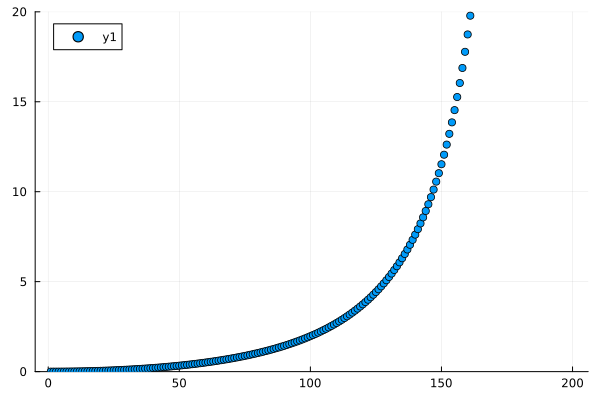

In [254]:
scatter(x[1:end],ylims=[0,20])

In [175]:
transpose(eigvec_A[:,1]) * W *  (L0 + L1 * eigval[1] + L2 * eigval[1]^2) * eigvec[:,1] 

-2.5231400965292052e-9 - 3.589076143430502e-9im

In [176]:
transpose((L0_A + L1_A * eigval_A[1] + L2_A * eigval_A[1]^2) * eigvec_A[:,1]) * eigvec[:,1]

4.472412236275411e-10 - 9.805325926180741e-11im

In [178]:
transpose(eigvec_A[:,2]) * W * (L0 + L1 * eigval_A[2] + L2 * eigval_A[1]^2) * eigvec[:,1]

0.00018317866244265887 + 1.6473623216755467e-5im

In [ ]:
Q = (transpose(eigvec_A[:,1]) * W * (L1 + (eigval[1]+eigval_A[1]) * L2) * eigvec[:,1])
abs.(Q)

DimensionMismatch: DimensionMismatch: first array has length 991 which does not match the length of the second, 200.

In [ ]:
scatter(abs.(q_all),xlims=[0,2000],ylims=[0,2],size=(800,500),markersize=abs.(6),mc=:black,grid=false,label=false ,framestyle=:box,xlabel="number of eigenvalues", ylabel="Q")

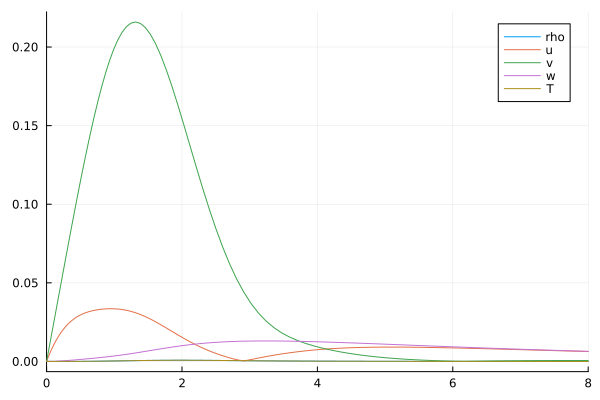

In [114]:
plot(z,abs.(vel[1]),label = "rho",xlims=[0,8]) 
plot!(z,abs.(vel[2]),label = "u")
plot!(z,abs.(vel[3]),label = "v")
plot!(z,abs.(vel[4]),label = "w")
plot!(z,abs.(vel[5]),label = "T") 

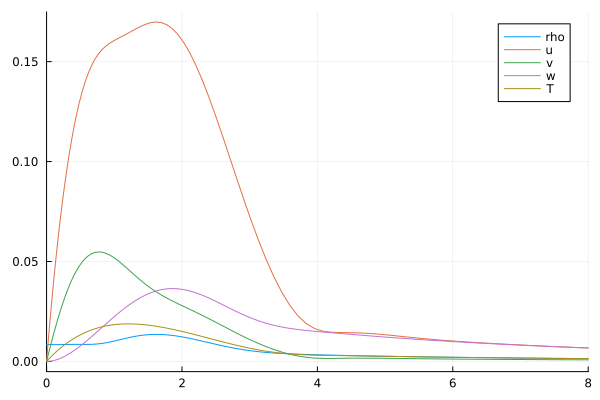

In [115]:
plot(z,abs.(vel_A[1]),label = "rho",xlims=[0,8]) 
plot!(z,abs.(vel_A[2]),label = "u")
plot!(z,abs.(vel_A[3]),label = "v")
plot!(z,abs.(vel_A[4]),label = "w")
plot!(z,abs.(vel_A[5]),label = "T") 

In [ ]:
((vel_A[1]))[1]

In [ ]:
plot(z,abs.(D*(vel_A[3])),xlims=[0,8])

In [ ]:
N_cheb = 99
Ro = -1
Tw = 1
Mr = 0.3
gamma = 1.4
sigma = 0.72
Co = 2-Ro-Ro^2
F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
n = 30
num = 1
data = [0 0 0 0 0]
for R = 260 : 2 : 290
# R = 320
    omega = 0/R
    be = n/R
    Ma = Mr/R
    cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
    L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega)
    L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
    nep = PEP([L0,L1,L2]);
    eigval,eigvec = iar(nep, σ = 0.5, neigs = 1,maxit = 500 , tol=1e-12)
    vel_full,vel = eig_full(eigvec,N_cheb,1)
    A0_raw = transpose(cof.D1) + (im * be * transpose(cof.B)) - (im * omega * transpose(cof.Ta)) - (be^2 * transpose(cof.Vyy)) - transpose(cof.dC) - (im *be*transpose(cof.dVyz)) + transpose(cof.d2Vzz) - (transpose(cof.C) + im * be * transpose(cof.Vyz) - 2 * transpose(cof.dVzz)) * kron(I(5),D) + transpose(cof.Vzz) * kron(I(5),D2)
    A1_raw = (im * transpose(cof.A)) - (be * transpose(cof.Vxy)) - (im * transpose(cof.dVxz)) - (im * transpose(cof.Vxz)) * kron(I(5),D) 
    A2_raw = -transpose(cof.Vxx)
    L0_A,L1_A,L2_A = boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb)
    nep = PEP([L0_A,L1_A,L2_A]); 
    eigval_A,eigvec_A = iar(nep,σ = 0.5, neigs = 1 ,maxit = 500,tol = 1e-12)
    vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
    # u_hat = (vel[2] .* vel_A[2] + vel[3] .* vel_A[3] + vel[4] .* vel_A[4])
    # K = (F .* u_hat + vel[1] .* vel_A[2] + vel[2] .* vel_A[1]) - (im/R) * (eigvec[1] + eigvec_A[1]) * u_hat
    # eigvec_A = eigvec_A./sum(K)
    vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
    # data = [data;[R eigval_A findmax(abs.((vel_A[2])))[1] findmax(abs.((vel_A[3])))[1] findmax(abs.((vel_A[4])))[1]]]
    data = [data ; [R eigval_A (1/R)*abs.(D*vel_A[2])[1] (1/R)*abs.(D*vel_A[3])[1] (1/R)*abs.(D*vel_A[4])[1]]]
    writedlm("log.dat",data[2:end,:])
end

In [ ]:
function Q_cacu(cof,N_cheb,method)
    L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega)
    L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
    Zero = zeros(size(L0,1),size(L0,2))
    eye = I
    A0_raw = transpose(cof.D1) + (im * be * transpose(cof.B)) - (im * omega * transpose(cof.Ta)) - (be^2 * transpose(cof.Vyy)) - transpose(cof.dC) - (im *be*transpose(cof.dVyz)) + transpose(cof.d2Vzz) - (transpose(cof.C) + im * be * transpose(cof.Vyz) - 2 * transpose(cof.dVzz)) * kron(I(5),D) + transpose(cof.Vzz) * kron(I(5),D2)
    A1_raw = (im * transpose(cof.A)) - (be * transpose(cof.Vxy)) - (im * transpose(cof.dVxz)) - (im * transpose(cof.Vxz)) * kron(I(5),D) 
    A2_raw = -transpose(cof.Vxx)
    A0,A1,A2 = boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb)
    nep = PEP([L0,L1,L2]);
    eigval,eigvec = iar(nep, σ = 0.6, neigs = 1,maxit = 500 , tol=1e-12)
    vel_full,vel = eig_full(eigvec,N_cheb,1)
    nep1 = PEP([A0,A1,A2]);
    eigval_A,eigvec_A = iar(nep1, σ = 0.6, neigs = 1,maxit = 500 , tol=1e-13)
    vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
    if method == 1
        H0 = [Zero -eye;L0 L1]
        H1 = [-eye Zero; Zero -L2]
        H0_A = [Zero -eye;A0 A1]
        H1_A = [-eye Zero; Zero -A2]
        C = eigs(H0,H1,nev=1,maxiter = 500,sigma = 0.5+0.005im, which=:SI)
        C_A = eigs(H0_A,H1_A,nev=1,maxiter = 500,sigma = 0.5+0.005im, which=:SI)
        vec_half = C[2][1:5*N_cheb-4,1]
        vec_A_half = C_A[2][1:5*N_cheb-4,1]
        vel_full,vel = eig_full(vec_half,N_cheb,1)
        vel_full_A,vel_A = eig_full(vec_A_half,N_cheb,1)
        # vec_L = C[2]./findmax(abs.(vel[3]))[1]
        # vec_A = C_A[2]./findmax(abs.(vel_A[3]))[1]
        vec_L = C[2]
        vec_A = C_A[2]
        vec_half = vec_L[1:5*N_cheb-4,1]
        vec_A_half = vec_A[1:5*N_cheb-4,1]
        vel_full,vel = eig_full(vec_half,N_cheb,1)
        vel_full_A,vel_A = eig_full(vec_A_half,N_cheb,1)
        Q = transpose(vec_A) * (H1 * vec_L)
    elseif method == 2
        u_hat = (vel[2] .* vel_A[2] + vel[3] .* vel_A[3] + vel[4] .* vel_A[4])
        K = F .* u_hat + vel[1] .* vel_A[2] + vel[2] .* vel_A[1] - (im/R) * (eigvec[1] + eigvec_A[1]) * u_hat
        eigvec_A = eigvec_A./sum(K)  
        eigvec = eigvec./findmax(abs.(vel[3]))[1]
        vel_full,vel = eig_full(eigvec,N_cheb,1)  
        vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
        Q = (transpose(eigvec_A[:,1]) * (L1 + (eigval[1]+eigval_A[1]) * L2) * eigvec[:,1])
    end
    return Q,vel_A,eigval,eigval_A
end

In [166]:
function caculate_cr1()
    N_cheb = 199
    Ro = -1
    Tw = 0.9
    Mr = 0.3
    gamma = 1.4
    sigma = 0.72
    Co = 2-Ro-Ro^2
    num = 1
    F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
    coff = [0 0 0 0 0 0 0 0 0]
    n = 25
    c = 0.5
    c_A = 0.5
    Wcc = zeros(N_cheb + 1,N_cheb + 1)
    for i = 1 : 1 : N_cheb
        Wcc[i,i] = z[i + 1] - z[i]
    end
    W = kron(I(5),Wcc)
    W = W[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]

    for R = 280 : 2 : 320
        omega = 0/R
        be = n/R
        Ma = Mr/R
        cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
        L0_raw,L1_raw,L2_raw = assemble_mat(cof,D,D2,be,omega)
        L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
        nep = PEP([L0,L1,L2]);
        eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=1e-12)
        c = real(eigval[1])
        vel_full,vel = eig_full(eigvec,N_cheb,1)
        A0 = transpose(cof.D1) + (im * be * transpose(cof.B)) - (im * omega * transpose(cof.Ta)) - (be^2 * transpose(cof.Vyy)) - transpose(cof.dC) - (im *be*transpose(cof.dVyz)) + transpose(cof.d2Vzz) - (transpose(cof.C) + im * be * transpose(cof.Vyz) - 2 * transpose(cof.dVzz)) * kron(I(5),D) + transpose(cof.Vzz) * kron(I(5),D2)
        A1 = (im * transpose(cof.A)) - (be * transpose(cof.Vxy)) - (im * transpose(cof.dVxz)) - (im * transpose(cof.Vxz)) * kron(I(5),D) 
        A2 = -transpose(cof.Vxx)
        L0_A,L1_A,L2_A = boudary_condition(A0,A1,A2,N_cheb)
        nep1 = PEP([L0_A,L1_A,L2_A]);
        eigval_A,eigvec_A = iar(nep1, σ = c_A, neigs = 1,maxit = 500 , tol=1e-14)
        c_A = real(eigval_A[1])
        vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
        eigvec = eigvec./findmax(abs.(vel[3]))[1]
        eigvec_A = eigvec_A./findmax(abs.(vel_A[2]))[1]
        vel_full,vel = eig_full(eigvec,N_cheb,1)  
        vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
        Q = (transpose(eigvec_A[:,1]) * W * (L1 + (2*eigval_A[1]) * L2) * eigvec[:,1])
        # x0 = R
        # u_wall = -(D*F)[1] * exp(-eigval[1] * (2 * eigval[1]))
        # v_wall = -(D*G)[1] * exp(-eigval[1] * (2 * eigval[1]))
        # w_wall = 0
        # rho_wall = -(D*rho)[1] * exp(-eigval[1] * (2 * eigval[1]))
        # T_wall = -(D*T)[1] * exp(-eigval[1] * (2 * eigval[1]))
        rho_wall = (1/2pi)*(D*rho)[1]
        u_wall = (1/2pi)*(D*F)[1]
        v_wall = (1/2pi)*(D*G)[1]
        w_wall = 0
        T_wall = (1/2*im*pi)*(D*T)[1]
        item_2 = rho[1] * (D*vel_A[2])[1] * u_wall
        item_3 = rho[1] * (D*vel_A[3])[1] * v_wall
        item_5 = rho[1]^2 * (T[1]/sigma) * (D*(vel_A[5]))[1] * T_wall
        BC =  item_2 + item_3 + item_5
        Cr = abs(-im * BC/Q[1])
        # coff = [coff;[R Cr real(eigval) imag(eigval) abs(Q[1]) abs(BC)]]
        coff = [coff;[n R Cr abs(Q[1]) abs(BC) real(eigval) imag(eigval) real(eigval_A) imag(eigval_A)]]
        writedlm("Cr_lof.dat",coff[2:end,:])
    end
    return coff
end

caculate_cr1 (generic function with 1 method)

In [167]:
coff = caculate_cr1(); 

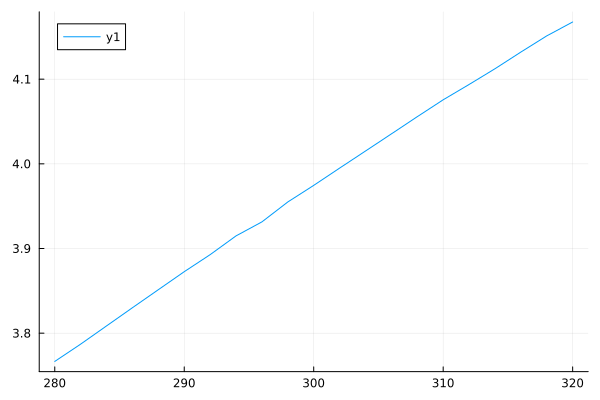

In [171]:
plot(real(coff[2:end,2]),real(coff[2:end,4]))

In [ ]:
function caculate_cr()
    N_cheb = 99
    Ro = -1
    for Tw in (0.8 ,0.9, 1.0 ,1.1 ,1.2)
        for Mr in (0.3:0.6)
            gamma = 1.4
            sigma = 0.72
            Co = 2-Ro-Ro^2
            num = 1
            F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
            coff = [0 0 0 0 0]
            for n = 25 : 1 : 40
                c = c_A = 0.7
                for R = 200 : 2 : 400
                    omega = 0/R
                    be = n/R
                    Ma = Mr/R
                    cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
                    L0_raw,L1_raw,L2_raw = assemble_mat(cof,D,D2,be,omega)
                    L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
                    nep = PEP([L0,L1,L2]);
                    eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=2e-12)
                    c = real(eigval[1])
                    vel_full,vel = eig_full(eigvec,N_cheb,1)
                    A0 = transpose(cof.D1) + (im * be * transpose(cof.B)) - (im * omega * transpose(cof.Ta)) - (be^2 * transpose(cof.Vyy)) - transpose(cof.dC) - (im *be*transpose(cof.dVyz)) + transpose(cof.d2Vzz) - (transpose(cof.C) + im * be * transpose(cof.Vyz) - 2 * transpose(cof.dVzz)) * kron(I(5),D) + transpose(cof.Vzz) * kron(I(5),D2)
                    A1 = (im * transpose(cof.A)) - (be * transpose(cof.Vxy)) - (im * transpose(cof.dVxz)) - (im * transpose(cof.Vxz)) * kron(I(5),D) 
                    A2 = -transpose(cof.Vxx)
                    L0_A,L1_A,L2_A = boudary_condition(A0,A1,A2,N_cheb)
                    nep1 = PEP([L0_A,L1_A,L2_A]);
                    eigval_A,eigvec_A = iar(nep1, σ = c_A, neigs = 1,maxit = 500 , tol=1e-13)
                    c_A = real(eigval_A[1])
                    vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
                    eigvec = eigvec./findmax(abs.(vel[3]))[1]
                    eigvec_A = eigvec_A./findmax(abs.(vel_A[2]))[1]
                    vel_full,vel = eig_full(eigvec,N_cheb,1)  
                    vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
                    Q = (transpose(eigvec_A[:,1]) * (L1 + (eigval[1]+eigval_A[1]) * L2) * eigvec[:,1])
                    # x0 = R
                    # u_wall = -(D*F)[1] * exp(-eigval[1] * (2 * eigval[1]))
                    # v_wall = -(D*G)[1] * exp(-eigval[1] * (2 * eigval[1]))
                    # w_wall = 0
                    # rho_wall = -(D*rho)[1] * exp(-eigval[1] * (2 * eigval[1]))
                    # T_wall = -(D*T)[1] * exp(-eigval[1] * (2 * eigval[1]))
                    rho_wall = -(1/2pi)*(D*rho)[1]
                    u_wall = -(1/2pi)*(D*F)[1]
                    v_wall = -(1/2pi)*(D*G)[1]
                    w_wall = 0
                    T_wall = -(1/2pi)*(D*T)[1]
                    item_2 = rho[1] * (D*(vel_A[2]))[1] * u_wall
                    item_3 = rho[1] * (D*(vel_A[3]))[1] * v_wall
                    item_5 = rho[1]^2 * (T[1]/sigma) * (D*(vel_A[5]))[1] * T_wall
                    BC =  item_2 + item_3 + item_5
                    Cr = abs(-im * BC/Q[1])
                    # coff = [coff;[R Cr real(eigval) imag(eigval) abs(Q[1]) abs(BC)]]
                    coff = [coff;[n R Cr real(eigval) imag(eigval)]]
                    writedlm("Cr_lof_$(Mr)_$(Tw).dat",coff[2:end,:])
                end
            end
        end
    end
end

In [ ]:
caculate_cr()

In [ ]:
plot(real(coff[2:end,2]),real(coff[2:end,3]))
# plot!(real(coff[2:end,1]),abs.(coff[2:end,3]))

In [ ]:
plot(real(coff[2:end,1]),derivative1(real(coff[2:end,2]),0.1))